<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/Multivariate_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, Concatenate, Attention, Layer
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler

In [2]:
# --- 1. DATA INGESTION (THE MACRO UNIVERSE) ---
# We are building a "Global Macro" dataset.
tickers = {
    'SPY': 'SPY',
    'VIX': '^VIX',
    '10Y': '^TNX', # 10 Year Treasury
    '2Y': '^IRX',  # 13 Week T-Bill (proxy for short term rates)
    'DXY': 'DX-Y.NYB', # Dollar Index
    'OIL': 'CL=F' # Crude Oil Futures
}

print("📥 Ingesting Macro Data...")
df_raw = yf.download(list(tickers.values()), start='2000-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']
df_raw.columns = tickers.keys() # Rename for sanity

# Forward Fill: Essential because Futures/Forex markets have different holidays than NYSE
df_raw.ffill(inplace=True)
df_raw.dropna(inplace=True)
df_raw.head()

📥 Ingesting Macro Data...


,SPY,VIX,10Y,2Y,DXY,OIL
Date,,,,,,
2000-08-23,32.049999,111.419998,95.488464,6.09,5.725,17.379999
2000-08-24,31.629999,111.230003,95.785225,6.09,5.716,17.040001
2000-08-25,32.049999,111.349998,95.745605,6.11,5.721,16.530001
2000-08-28,32.869999,111.459999,96.072037,6.13,5.766,16.540001
2000-08-29,32.720001,112.199997,96.091850,6.12,5.808,16.889999


In [3]:
# --- 2. FEATURE ENGINEERING (FINANCIAL LOGIC) ---
df = pd.DataFrame()

# A. TARGET: SPY Log Returns
df['SPY_Ret'] = np.log(df_raw['SPY'] / df_raw['SPY'].shift(1))
df.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,SPY_Ret
Date,
2000-08-23,NaN
2000-08-24,-0.013191
2000-08-25,0.013191
2000-08-28,0.025263
2000-08-29,-0.004574


In [4]:
# B. MACRO FEATURES
# Yield Curve: The difference between Long and Short rates.
# (Normalizing raw yields by differencing them first is safer for stationarity)
df['10Y_Diff'] = df_raw['10Y'].diff()
df['Yield_Curve'] = df_raw['10Y'] - df_raw['2Y'] # Raw level is informative, but non-stationary? Let's check diff.
df['Yield_Curve_Diff'] = df['Yield_Curve'].diff()

# VIX: Use raw changes (Vol of Vol)
df['VIX_Diff'] = df_raw['VIX'].diff()

# Dollar & Oil: Log Returns (Standard for assets)
df['DXY_Ret'] = np.log(df_raw['DXY'] / df_raw['DXY'].shift(1))
df['OIL_Ret'] = np.log(df_raw['OIL'] / df_raw['OIL'].shift(1))
df.head()

,SPY_Ret,10Y_Diff,Yield_Curve,Yield_Curve_Diff,VIX_Diff,DXY_Ret,OIL_Ret
Date,,,,,,,
2000-08-23,NaN,NaN,89.398464,NaN,NaN,NaN,NaN
2000-08-24,-0.013191,0.296761,89.695225,0.296761,-0.189995,-0.001573,-0.019756
2000-08-25,0.013191,-0.039619,89.635605,-0.059619,0.119995,0.000874,-0.030387
2000-08-28,0.025263,0.326431,89.942037,0.306431,0.110001,0.007835,0.000605
2000-08-29,-0.004574,0.019814,89.971850,0.029814,0.739998,0.007258,0.020940


In [5]:
# C. TARGET VARIABLE (CLASSIFICATION)
# 1 if Next Day SPY > 0, else 0
df['Target'] = np.where(df['SPY_Ret'].shift(-1) > 0, 1, 0)

# Drop NaNs created by lags/diffs
df.dropna(inplace=True)
df.head()

,SPY_Ret,10Y_Diff,Yield_Curve,Yield_Curve_Diff,VIX_Diff,DXY_Ret,OIL_Ret,Target
Date,,,,,,,,
2000-08-24,-0.013191,0.296761,89.695225,0.296761,-0.189995,-0.001573,-0.019756,1
2000-08-25,0.013191,-0.039619,89.635605,-0.059619,0.119995,0.000874,-0.030387,1
2000-08-28,0.025263,0.326431,89.942037,0.306431,0.110001,0.007835,0.000605,0
2000-08-29,-0.004574,0.019814,89.971850,0.029814,0.739998,0.007258,0.020940,1
2000-08-30,0.020569,-0.919868,89.051982,-0.919868,-0.059998,-0.001378,0.046278,0


In [6]:
# --- 3. STATIONARITY CHECK (ADF TEST) ---
# A Quant MUST prove their data doesn't have a unit root (trend).
print("\n🔎 STATIONARITY CHECK (Augmented Dickey-Fuller)")
print(f"{'Feature':<20} | {'P-Value':<10} | {'Stationary?'}")
print("-" * 50)

valid_features = []
for col in df.columns:
    if col == 'Target': continue
    res = adfuller(df[col])
    p_val = res[1]
    is_stat = "✅ Yes" if p_val < 0.05 else "❌ NO"
    print(f"{col:<20} | {p_val:.5f}    | {is_stat}")

    # We only keep stationary features for the Neural Net
    if p_val < 0.05:
        valid_features.append(col)

print(f"\nFinal Feature Set: {valid_features}")


🔎 STATIONARITY CHECK (Augmented Dickey-Fuller)
Feature              | P-Value    | Stationary?
--------------------------------------------------
SPY_Ret              | 0.00000    | ✅ Yes
10Y_Diff             | 0.00000    | ✅ Yes
Yield_Curve          | 0.99851    | ❌ NO
Yield_Curve_Diff     | 0.00000    | ✅ Yes
VIX_Diff             | 0.00000    | ✅ Yes
DXY_Ret              | 0.00000    | ✅ Yes
OIL_Ret              | 0.00000    | ✅ Yes

Final Feature Set: ['SPY_Ret', '10Y_Diff', 'Yield_Curve_Diff', 'VIX_Diff', 'DXY_Ret', 'OIL_Ret']


In [7]:
# --- 4. MULTICOLLINEARITY CHECK (VIF) ---
# We calculate VIF for each feature.
X_vif = df[valid_features]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n🔎 MULTICOLLINEARITY CHECK (VIF)")
print(vif_data.sort_values('VIF', ascending=False))

# Filter out high VIF features (Threshold = 5 or 10)
final_features = vif_data[vif_data['VIF'] < 10]['Feature'].tolist()
print(f"\nSelected Low-Collinearity Features: {final_features}")


🔎 MULTICOLLINEARITY CHECK (VIF)
            Feature          VIF
1          10Y_Diff  2432.730591
2  Yield_Curve_Diff  2425.339503
5           OIL_Ret     1.788208
4           DXY_Ret     1.164939
0           SPY_Ret     1.096414
3          VIX_Diff     1.080471

Selected Low-Collinearity Features: ['SPY_Ret', 'VIX_Diff', 'DXY_Ret', 'OIL_Ret']


In [8]:
# --- 5. DATA SCALING & SHAPING ---
# Standard Scaler (Z-Score) is better for deep learning than MinMax when outliers exist
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[final_features])
y = df['Target'].values

# Create 3D Cube
X_3d = []
y_3d = []
seq_len = 60

for i in range(seq_len, len(X_scaled)):
    X_3d.append(X_scaled[i-seq_len:i])
    y_3d.append(y[i])

X_3d, y_3d = np.array(X_3d), np.array(y_3d)

# Time Series Split (No Shuffle!)
split = int(len(X_3d) * 0.8)
X_train, X_test = X_3d[:split], X_3d[split:]
y_train, y_test = y_3d[:split], y_3d[split:]

In [9]:
# --- 6. MODEL: BI-DIRECTIONAL LSTM WITH ATTENTION ---
# Functional API is required for complex architectures (Sequential won't cut it)

def build_attention_model(input_shape):
    inputs = Input(shape=input_shape)

    # Bi-Directional LSTM
    # Returns the full sequence (return_sequences=True) so Attention can look at all days
    lstm_out = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    lstm_out = Dropout(0.3)(lstm_out)

    # Attention Layer
    # Queries = Value = Keys = lstm_out (Self-Attention)
    attn_out = Attention()([lstm_out, lstm_out])

    # Global Average Pooling (or Flatten) to compress the sequence
    # We take the attention-weighted sequence and average it
    pooled_out = tf.keras.layers.GlobalAveragePooling1D()(attn_out)

    # Dense Layers for reasoning
    dense_out = Dense(32, activation='relu')(pooled_out)
    dense_out = Dropout(0.2)(dense_out)

    # Output Probability
    outputs = Dense(1, activation='sigmoid')(dense_out)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [10]:
model = build_attention_model((seq_len, len(final_features)))

# OPTIMIZER: Adam with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'AUC'])

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 128)   │     35,328 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 60, 128)   │          0 │ dropout[0][0],    │
│ (Attention)         │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,489 (154.25 KB)

 Trainable params: 39,489 (154.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
# --- 7. TRAINING WITH EARLY STOPPING ---
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5)
    ],
    verbose=1
)

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - AUC: 0.4982 - accuracy: 0.5167 - loss: 0.6932 - val_AUC: 0.4903 - val_accuracy: 0.5317 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - AUC: 0.5216 - accuracy: 0.5216 - loss: 0.6923 - val_AUC: 0.5159 - val_accuracy: 0.5368 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - AUC: 0.5181 - accuracy: 0.5218 - loss: 0.6921 - val_AUC: 0.5208 - val_accuracy: 0.5360 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - AUC: 0.5448 - accuracy: 0.5343 - loss: 0.6908 - val_AUC: 0.5125 - val_accuracy: 0.5197 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - AUC: 0.5116 - accuracy: 0.5272 - loss: 0.6917 - val_AUC: 0.5083 - val_accuracy: 0.5308 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.5179 - ac

In [12]:
# --- 8. PROFESSIONAL BACKTEST SIMULATION ---

# Get Probabilities
preds_prob = model.predict(X_test).flatten()

# Create Backtest DataFrame
bt_df = pd.DataFrame({'Target': y_test, 'Prob': preds_prob})
bt_df.index = df.index[split+seq_len:]

# Bring back the actual returns (unscaled) for PnL calculation
bt_df['SPY_Ret'] = df['SPY_Ret'].iloc[split+seq_len:].values

# STRATEGY LOGIC
# Long if Prob > 0.55, Short if Prob < 0.45, else Cash (0)
# (Adjust thresholds to tune aggression)
long_threshold = 0.55
short_threshold = 0.45

bt_df['Position'] = np.where(bt_df['Prob'] > long_threshold, 1,
                             np.where(bt_df['Prob'] < short_threshold, -1, 0))

# Shift Position by 1 (We trade 'tomorrow' based on 'today's' signal)
bt_df['Position'] = bt_df['Position'].shift(1).fillna(0)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [13]:
# CALCULATE RETURNS
# Strategy Return = Position * Market Return
bt_df['Strat_Ret_Gross'] = bt_df['Position'] * bt_df['SPY_Ret']

# TRANSACTION COSTS
# If position changed, we pay 5bps (0.0005)
bt_df['Trade_Count'] = bt_df['Position'].diff().abs() # 0, 1, or 2 (flip)
cost_per_trade = 0.0005
bt_df['Cost'] = bt_df['Trade_Count'] * cost_per_trade
bt_df['Strat_Ret_Net'] = bt_df['Strat_Ret_Gross'] - bt_df['Cost']

In [14]:
# CUMULATIVE RETURNS (EQUITY CURVE)
bt_df['Equity_Strat'] = (1 + bt_df['Strat_Ret_Net']).cumprod()
bt_df['Equity_BuyHold'] = (1 + bt_df['SPY_Ret']).cumprod()

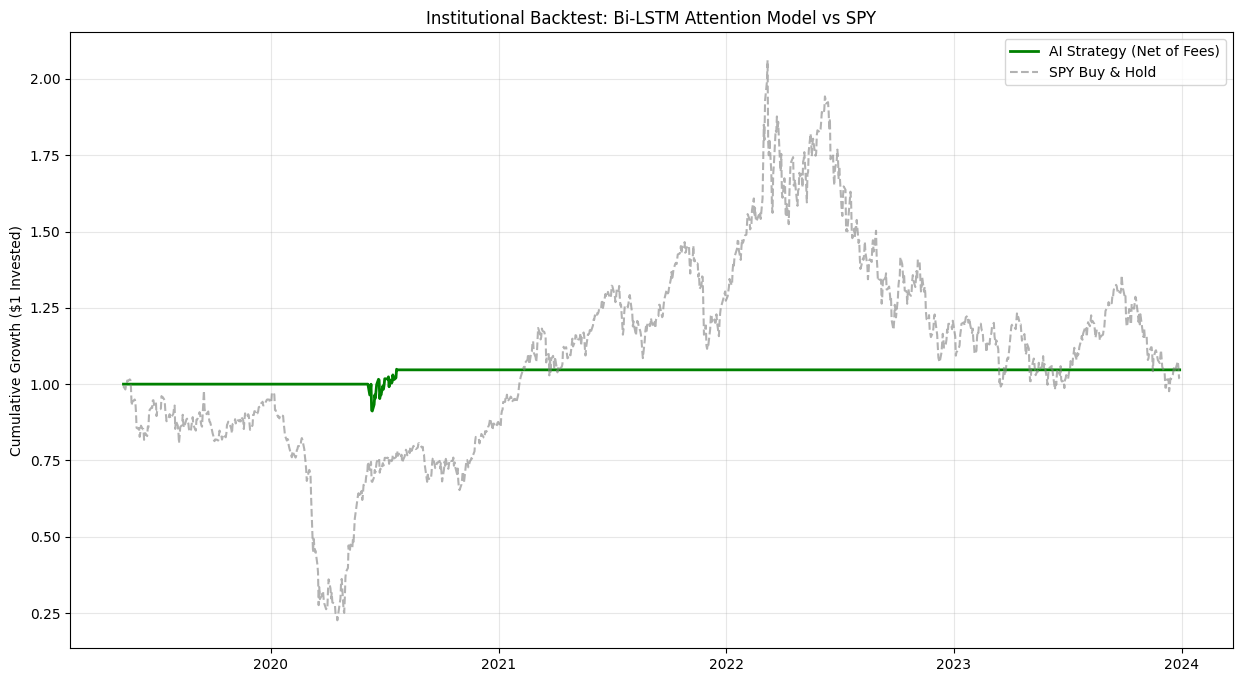

In [15]:
# --- 9. VISUALIZATION: THE BOARDROOM CHART ---
plt.figure(figsize=(15, 8))

# Plot Equity Curves
plt.plot(bt_df['Equity_Strat'], label='AI Strategy (Net of Fees)', color='green', linewidth=2)
plt.plot(bt_df['Equity_BuyHold'], label='SPY Buy & Hold', color='gray', linestyle='--', alpha=0.6)

plt.title("Institutional Backtest: Bi-LSTM Attention Model vs SPY")
plt.ylabel("Cumulative Growth ($1 Invested)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# --- 10. RISK METRICS ---

def calculate_sharpe(returns):
    return returns.mean() / returns.std() * np.sqrt(252)

def calculate_max_drawdown(equity_curve):
    peak = equity_curve.cummax()
    drawdown = (equity_curve - peak) / peak
    return drawdown.min()

def calculate_sortino(returns):
    # Sortino only penalizes negative volatility
    downside_returns = returns[returns < 0]
    return returns.mean() / downside_returns.std() * np.sqrt(252)

In [17]:
strat_sharpe = calculate_sharpe(bt_df['Strat_Ret_Net'])
hold_sharpe = calculate_sharpe(bt_df['SPY_Ret'])

strat_dd = calculate_max_drawdown(bt_df['Equity_Strat'])
hold_dd = calculate_max_drawdown(bt_df['Equity_BuyHold'])

strat_sortino = calculate_sortino(bt_df['Strat_Ret_Net'])

print(f"------------------------------------------------")
print(f"📊 PERFORMANCE REPORT (Net of 5bps Fees)")
print(f"------------------------------------------------")
print(f"{'Metric':<20} | {'AI Strategy':<15} | {'Buy & Hold':<15}")
print(f"-" * 55)
print(f"{'Sharpe Ratio':<20} | {strat_sharpe:.4f}          | {hold_sharpe:.4f}")
print(f"{'Sortino Ratio':<20} | {strat_sortino:.4f}          | {'N/A'}")
print(f"{'Max Drawdown':<20} | {strat_dd*100:.2f}%          | {hold_dd*100:.2f}%")
print(f"{'Total Return':<20} | {(bt_df['Equity_Strat'].iloc[-1]-1)*100:.2f}%         | {(bt_df['Equity_BuyHold'].iloc[-1]-1)*100:.2f}%")
print(f"------------------------------------------------")

------------------------------------------------
📊 PERFORMANCE REPORT (Net of 5bps Fees)
------------------------------------------------
Metric               | AI Strategy     | Buy & Hold     
-------------------------------------------------------
Sharpe Ratio         | 0.1803          | 0.2886
Sortino Ratio        | 0.0313          | N/A
Max Drawdown         | -8.81%          | -77.71%
Total Return         | 4.68%         | 1.81%
------------------------------------------------


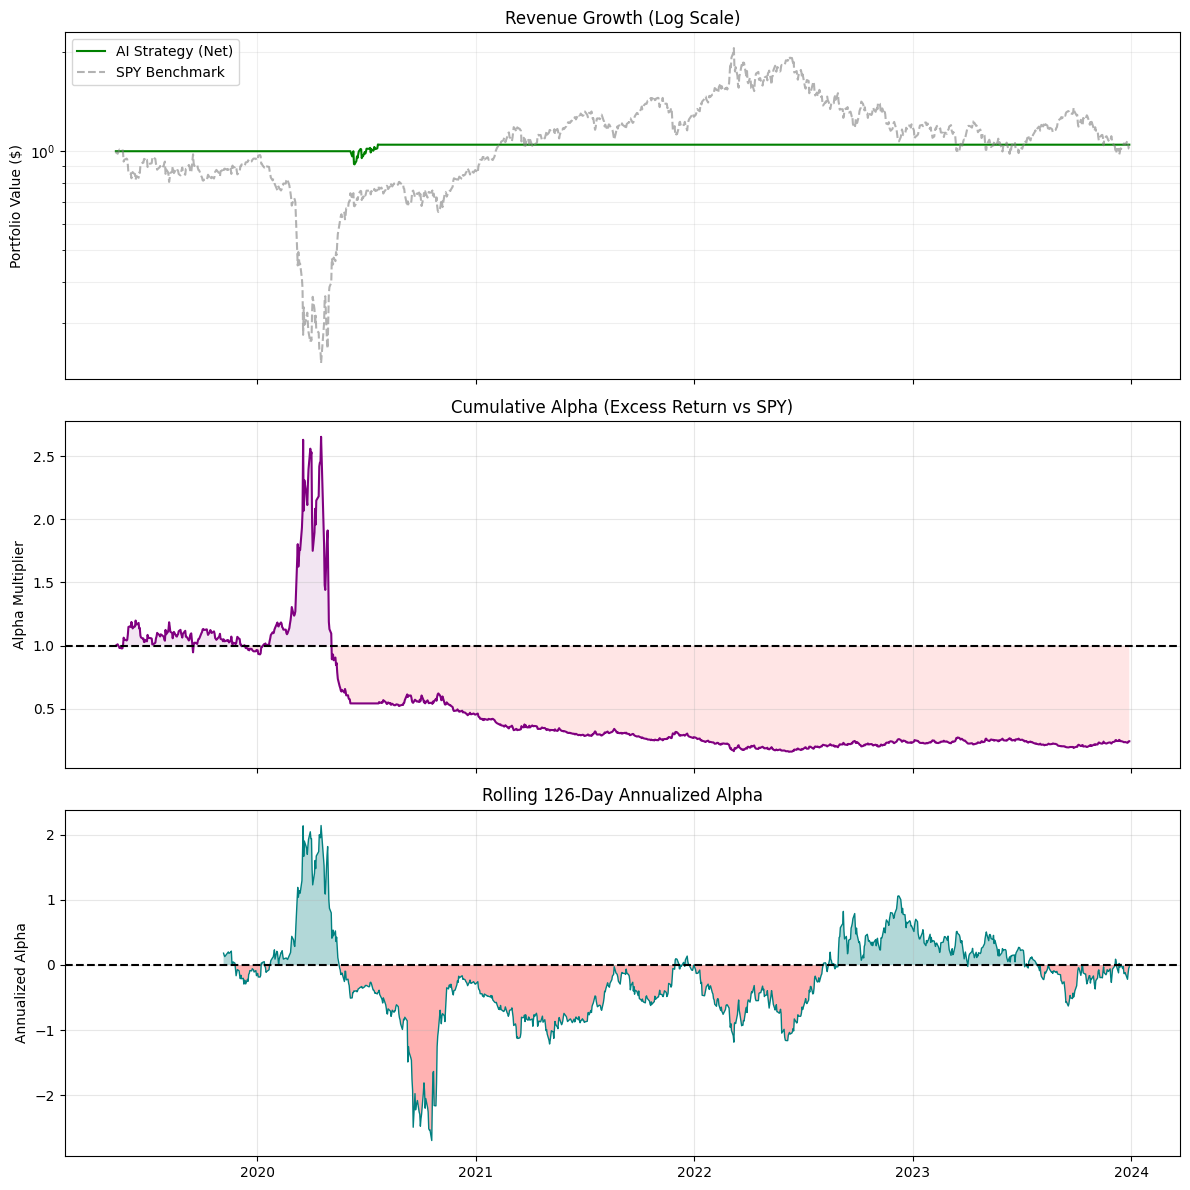

In [18]:
# --- 11. REVENUE & ALPHA VISUALIZATION ---
import matplotlib.ticker as mtick

# A. Calculate Cumulative Alpha (The "Value Add")
# Alpha = Strategy Return - Benchmark Return
bt_df['Daily_Alpha'] = bt_df['Strat_Ret_Net'] - bt_df['SPY_Ret']
bt_df['Cumulative_Alpha'] = (1 + bt_df['Daily_Alpha']).cumprod()

# B. Rolling Alpha (6-Month Window) - "Are we hot or cold?"
# Annualized Rolling Alpha
window = 126 # 6 months
bt_df['Rolling_Alpha'] = bt_df['Daily_Alpha'].rolling(window).mean() * 252

# --- PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Revenue Growth (Log Scale is pro standard for long periods)
axes[0].plot(bt_df['Equity_Strat'], label='AI Strategy (Net)', color='green', linewidth=1.5)
axes[0].plot(bt_df['Equity_BuyHold'], label='SPY Benchmark', color='gray', linestyle='--', alpha=0.6)
axes[0].set_yscale('log') # Log scale reveals percentage growth better
axes[0].set_title('Revenue Growth (Log Scale)')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(loc='upper left')
axes[0].grid(True, which="both", ls="-", alpha=0.2)

# Plot 2: The "Alpha Generation" Curve
# If this line goes UP, you are beating the market purely on skill.
axes[1].plot(bt_df['Cumulative_Alpha'], color='purple', linewidth=1.5)
axes[1].fill_between(bt_df.index, bt_df['Cumulative_Alpha'], 1.0, where=(bt_df['Cumulative_Alpha']>=1), facecolor='purple', alpha=0.1)
axes[1].fill_between(bt_df.index, bt_df['Cumulative_Alpha'], 1.0, where=(bt_df['Cumulative_Alpha']<1), facecolor='red', alpha=0.1)
axes[1].axhline(1.0, color='black', linestyle='--')
axes[1].set_title('Cumulative Alpha (Excess Return vs SPY)')
axes[1].set_ylabel('Alpha Multiplier')
axes[1].grid(True, alpha=0.3)

# Plot 3: Rolling Alpha (Consistency Check)
axes[2].plot(bt_df['Rolling_Alpha'], color='teal', linewidth=1)
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title(f'Rolling {window}-Day Annualized Alpha')
axes[2].set_ylabel('Annualized Alpha')
axes[2].fill_between(bt_df.index, bt_df['Rolling_Alpha'], 0, where=(bt_df['Rolling_Alpha']>=0), facecolor='teal', alpha=0.3)
axes[2].fill_between(bt_df.index, bt_df['Rolling_Alpha'], 0, where=(bt_df['Rolling_Alpha']<0), facecolor='red', alpha=0.3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------------
💰 TRADING STATISTICS
------------------------------------------------
Win Rate             | 53.12%
Profit Factor        | 1.21 (Target > 1.5)
Avg Win / Avg Loss   | 1.07
Kelly Criterion      | 9.18% (Aggressive Size)
------------------------------------------------


/tmp/ipython-input-3448005809.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ret = bt_df['Strat_Ret_Net'].resample('M').apply(lambda x: (1 + x).prod() - 1)


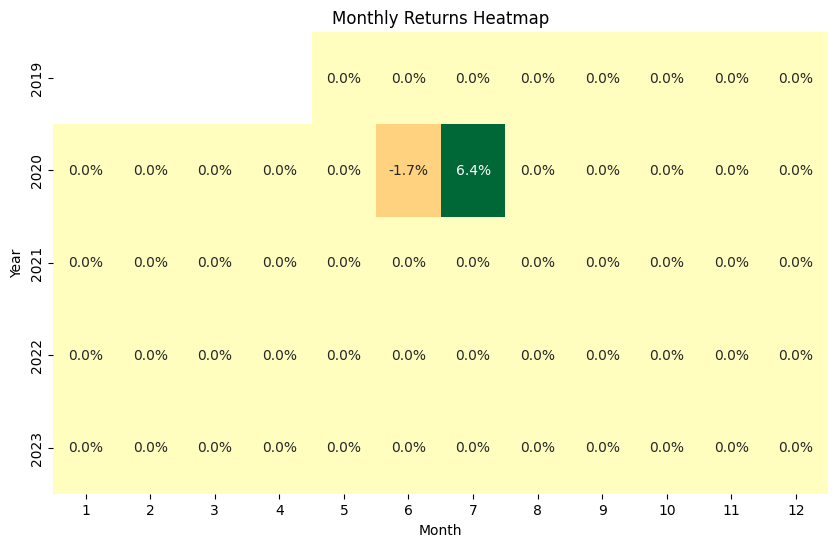

In [21]:
# --- 13. PROFESSIONAL TEAR SHEET METRICS ---

# Filter for days we actually traded (Position != 0)
trades = bt_df[bt_df['Position'] != 0].copy()
# Daily PnL for active days
trades['Daily_PnL'] = trades['Strat_Ret_Net']

# A. Win Rate & Profit Factor
wins = trades[trades['Daily_PnL'] > 0]['Daily_PnL']
losses = trades[trades['Daily_PnL'] < 0]['Daily_PnL']
# print(trades.head())

win_rate = len(wins) / len(trades)
avg_win = wins.mean()
avg_loss = abs(losses.mean())
profit_factor = wins.sum() / abs(losses.sum())

print(f"------------------------------------------------")
print(f"💰 TRADING STATISTICS")
print(f"------------------------------------------------")
print(f"{'Win Rate':<20} | {win_rate*100:.2f}%")
print(f"{'Profit Factor':<20} | {profit_factor:.2f} (Target > 1.5)")
print(f"{'Avg Win / Avg Loss':<20} | {avg_win/avg_loss:.2f}")
print(f"{'Kelly Criterion':<20} | {(win_rate - (1-win_rate)/(avg_win/avg_loss))*100:.2f}% (Aggressive Size)")
print(f"------------------------------------------------")

# B. Monthly Returns Heatmap (The "Calendar")
# We need to resample our daily returns to monthly
monthly_ret = bt_df['Strat_Ret_Net'].resample('M').apply(lambda x: (1 + x).prod() - 1)
monthly_ret_df = pd.DataFrame(monthly_ret)
monthly_ret_df['Year'] = monthly_ret_df.index.year
monthly_ret_df['Month'] = monthly_ret_df.index.month

# Pivot for Heatmap
heatmap_data = monthly_ret_df.pivot(index='Year', columns='Month', values='Strat_Ret_Net')

import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap='RdYlGn', center=0, cbar=False)
plt.title("Monthly Returns Heatmap")
plt.ylabel("Year")
plt.xlabel("Month")
plt.show()